# Basic Climate Analysis – Western Australia

**Complete workflow: DJF climatologies, climate change signal, anomaly time series + GIS exports**

**NARCliM2.0 `tasmax` analysis** over Western Australia using time-chunked loading:

| Analysis | Description |
|----------|-------------|
| DJF reference climatology (1980–2009) | 30-year historical mean |
| DJF future climatology (2070–2099, SSP3-7.0) | 30-year future mean |
| Climate change signal | Future minus historical DJF mean |
| DJF anomaly time series (1951–2100) | Annual DJF minus reference, averaged over WA |
| Seasonal maps & Perth time series | GIS-ready NetCDF exports |



<a id="top"></a>
## Notebook structure

- [Configuration](#Configuration)
- [Imports](#Imports)
- [Helper functions](#Helper-functions)
- [Build THREDDS URLs](#Build-THREDDS-URLs)
- [Time-chunked DJF loading](#Time-chunked-DJF-loading)
- [WA spatial mask](#WA-spatial-mask)
- [DJF climatologies and climate change signal](#DJF-climatologies-and-climate-change-signal)
- [DJF anomaly time series](#DJF-anomaly-time-series)
- [Seasonal climatology maps](#Seasonal-climatology-maps)
- [Regrid for GIS export](#Regrid-for-GIS-export)
- [Export products](#Export-products)
- [Interpretation](#Interpretation)
- [Next steps](#Next-steps)


## Configuration

All analysis parameters are defined here. Change these values to customise the analysis without touching any other cell.


In [27]:
# ================================================================
# ANALYSIS CONFIGURATION — edit here only
# ================================================================

# --- Season of interest ---
SEASON = 'DJF'          # DJF = December–January–February (austral summer)

# --- Reference (historical climatology) period ---
REF_START = 1980        # Start year of reference period
REF_END   = 2009        # End year  of reference period (30 years)

# --- Future period ---
FUT_START = 2070        # Start year of future period
FUT_END   = 2099        # End year  of future period (30 years)

# --- Emissions scenario for future period ---
SCENARIO  = 'ssp370'    # Options: 'ssp126', 'ssp370'

# --- Full historical run extent ---
HIST_START = 1951
HIST_END   = 2014

# --- Full scenario run extent ---
SCEN_START = 2015
SCEN_END   = 2100

# --- Western Australia bounding box (degrees) ---
LON_MIN, LON_MAX = 112, 129
LAT_MIN, LAT_MAX = -36, -13

# --- Point of interest for time-series export ---
TARGET_LON, TARGET_LAT = 116.0, -32.0
TARGET_LABEL = 'Perth'

# --- NARCliM2.0 THREDDS URL template ---
# {scenario} and {period} (YYYYMM-YYYYMM) are filled at runtime
THREDDS_TMPL = (
    'https://dapds00.nci.org.au/thredds/dodsC/zz63/NARCliM2-0/output-CMIP6/DD/'
    'AUS-18/NSW-Government/ACCESS-ESM1-5/{scenario}/r6i1p1f1/'
    'NARCliM2-0-WRF412R3/v1-r1/mon/tasmax/latest/'
    'tasmax_AUS-18_ACCESS-ESM1-5_{scenario}_r6i1p1f1_NSW-Government_'
    'NARCliM2-0-WRF412R3_v1-r1_mon_{period}.nc'
)

print('Configuration')
print(f'  Season            : {SEASON}')
print(f'  Reference period  : {REF_START}-{REF_END}')
print(f'  Future period     : {FUT_START}-{FUT_END} ({SCENARIO})')
print(f'  Historical run    : {HIST_START}-{HIST_END}')
print(f'  Scenario run      : {SCEN_START}-{SCEN_END}')
print(f'  WA lon            : {LON_MIN}-{LON_MAX} E')
print(f'  WA lat            : {LAT_MIN}-{LAT_MAX} N')


Configuration
  Season            : DJF
  Reference period  : 1980-2009
  Future period     : 2070-2099 (ssp370)
  Historical run    : 1951-2014
  Scenario run      : 2015-2100
  WA lon            : 112-129 E
  WA lat            : -36--13 N


<div style="text-align: right">
  <a href="#top">Go back to top</a>
</div>

## Imports

In [28]:
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

import os
os.environ['HDF5_USE_FILE_LOCKING'] = 'FALSE'   # suppress HDF5 format-probe warnings

import time
import gc
import xarray as xr
import numpy as np
import xesmf as xe
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import TwoSlopeNorm
from pathlib import Path
from climate_utils import kelvin_to_celsius

print('Imports OK')


Imports OK


<div style="text-align: right">
  <a href="#top">Go back to top</a>
</div>

## Helper functions

All reusable logic is collected here so the analysis cells stay clean.


In [29]:
# ------------------------------------------------------------------
# DJF year convention
# December belongs to the FOLLOWING year's DJF season:
#   Dec-2014 + Jan-2015 + Feb-2015  →  DJF-2015
# ------------------------------------------------------------------

DJF_MONTHS = [12, 1, 2]   # months that make up DJF

def is_djf(month):
    """Return True for December, January, February."""
    return month in DJF_MONTHS


def djf_year(year, month):
    """
    Return the DJF label year for a given calendar year+month.
    December is shifted to the next year.
    """
    return year + 1 if month == 12 else year


def build_wa_mask(ds):
    """2-D boolean mask for grid cells inside the WA bounding box."""
    lat2d = ds['lat']
    lon2d = (ds['lon'] + 360) % 360
    return (
        (lon2d >= LON_MIN) & (lon2d <= LON_MAX) &
        (lat2d >= LAT_MIN) & (lat2d <= LAT_MAX)
    )


def nearest_point(ds, tlon, tlat):
    """Return (rlat_idx, rlon_idx) of the grid cell nearest to (tlon, tlat)."""
    dist2 = (ds['lat'] - tlat)**2 + (ds['lon'] - tlon)**2
    idx = dist2.argmin(dim=('rlat', 'rlon'))
    return idx['rlat'].item(), idx['rlon'].item()


print('Helper functions defined.')


Helper functions defined.


<div style="text-align: right">
  <a href="#top">Go back to top</a>
</div>

## Build THREDDS URLs

One URL is constructed per year following the NARCliM2.0 file-naming convention `YYYYMM-YYYYMM` (annual files).


In [30]:
def make_urls(scenario, start_year, end_year):
    urls = []
    for yr in range(start_year, end_year + 1):
        period = f'{yr}01-{yr}12'
        urls.append(THREDDS_TMPL.format(scenario=scenario, period=period))
    return urls

hist_urls = make_urls('historical', HIST_START, HIST_END)
scen_urls = make_urls(SCENARIO,    SCEN_START, SCEN_END)

print(f'Historical URLs : {len(hist_urls)}  ({HIST_START}-{HIST_END})')
print(f'Scenario URLs   : {len(scen_urls)}  ({SCEN_START}-{SCEN_END}, {SCENARIO})')
print('Example:', hist_urls[0].split('/')[-1])


Historical URLs : 64  (1951-2014)
Scenario URLs   : 86  (2015-2100, ssp370)
Example: tasmax_AUS-18_ACCESS-ESM1-5_historical_r6i1p1f1_NSW-Government_NARCliM2-0-WRF412R3_v1-r1_mon_195101-195112.nc


<div style="text-align: right">
  <a href="#top">Go back to top</a>
</div>

## Time-chunked DJF loading

### Strategy

NARCliM2.0 files are chunked as `[1 time-step × full AUS-18 domain]`. Loading all 150 files in full would require ~75 GB. Instead:

1. **Time chunking**: only DJF months (Dec, Jan, Feb) are read from each file. The other 9 months are never downloaded — this cuts data volume by ~75%.
2. **Decade batching**: files are processed 10 at a time with a pause between batches to avoid overwhelming the THREDDS server.
3. **Immediate masking**: the WA mask is applied right after loading so non-WA data is discarded before accumulating results.

> **DJF note**: December is assigned to the *following* year's DJF season. So DJF-2015 = Dec-2014 + Jan-2015 + Feb-2015. This is handled by storing a `djf_year` coordinate alongside each time step.


In [31]:
def load_djf_chunked(urls, retries=3, wait=10, batch_pause=5):
    """
    Load only DJF months (Dec, Jan, Feb) from a list of annual OPeNDAP URLs.

    Strategy (time chunking):
      - Open each annual file.
      - Select only time steps where month is in [12, 1, 2]  → 75% less data.
      - Apply WA spatial mask immediately → discard non-WA cells.
      - Assign a djf_year coordinate (December → following year, capped at SCEN_END).
      - Load into memory and close the connection before the next file.

    Files are processed in batches of 10 with a pause between batches
    to avoid overwhelming the NCI THREDDS server.
    """
    all_slices = []

    batches = [urls[i:i+10] for i in range(0, len(urls), 10)]

    for b_idx, batch in enumerate(batches):
        # Extract 4-digit year from filename for the progress label
        y0 = batch[0].split('/')[-1].split('_mon_')[1][:4]
        y1 = batch[-1].split('/')[-1].split('_mon_')[1][:4]
        print(f'  Batch {b_idx+1}/{len(batches)} ({y0}-{y1})...')

        for url in batch:
            year_str = url.split('/')[-1].split('_mon_')[1][:4]
            for attempt in range(retries):
                try:
                    ds = xr.open_dataset(url)

                    # --- TIME CHUNKING: keep only DJF months ---
                    months   = ds['time.month'].values
                    djf_mask = np.isin(months, DJF_MONTHS)

                    if not djf_mask.any():
                        ds.close()
                        break   # no DJF months in file (shouldn't happen)

                    ds_djf = ds.isel(time=djf_mask)

                    # --- Spatial mask (NaN outside WA bounding box) ---
                    wa_mask = build_wa_mask(ds_djf)
                    da = kelvin_to_celsius(ds_djf['tasmax'].where(wa_mask))

                    # --- DJF-year coordinate ---
                    # December is shifted to the following year.
                    # Cap at SCEN_END so December-2100 stays as DJF-2100,
                    # not DJF-2101 (which does not exist in the dataset).
                    yr_vals  = ds_djf['time.year'].values
                    mon_vals = ds_djf['time.month'].values
                    djf_yrs  = np.array(
                        [min(djf_year(y, m), SCEN_END)
                         for y, m in zip(yr_vals, mon_vals)]
                    )
                    da = da.assign_coords(djf_year=('time', djf_yrs))

                    # --- Load into memory and release connection ---
                    da.load()
                    all_slices.append(da)
                    ds.close()
                    break

                except OSError:
                    if attempt < retries - 1:
                        print(f'    {year_str}: connection failed, '
                              f'retrying in {wait}s...')
                        time.sleep(wait)
                    else:
                        raise

        print(f'    Batch {b_idx+1} complete. Pausing {batch_pause}s...')
        time.sleep(batch_pause)

    return xr.concat(all_slices, dim='time')


print('load_djf_chunked() defined.')


load_djf_chunked() defined.


In [32]:
print(f'Loading historical DJF months ({HIST_START}-{HIST_END})...')
da_hist_djf = load_djf_chunked(hist_urls)

print(f'\nLoading scenario DJF months ({SCEN_START}-{SCEN_END}, {SCENARIO})...')
da_scen_djf = load_djf_chunked(scen_urls)

# Concatenate into one continuous DJF-only time series (1951-2100)
tasmax_djf = xr.concat([da_hist_djf, da_scen_djf], dim='time')

n_expected = (SCEN_END - HIST_START + 1) * 3
print(f'\nDone!')
print(f'  Time steps loaded : {tasmax_djf.shape[0]}  (expected ~{n_expected})')
print(f'  djf_year range    : {int(tasmax_djf.djf_year.min())} - '
      f'{int(tasmax_djf.djf_year.max())}  (expected {HIST_START}-{SCEN_END})')
print(f'  Spatial shape     : {tasmax_djf.shape[1]} rlat x {tasmax_djf.shape[2]} rlon')
print(f'  Memory            : {tasmax_djf.nbytes / 1e6:.0f} MB')

# Free intermediate arrays to recover memory
del da_hist_djf, da_scen_djf
gc.collect()


Loading historical DJF months (1951-2014)...
  Batch 1/7 (1951-1960)...
    Batch 1 complete. Pausing 5s...
  Batch 2/7 (1961-1970)...
    Batch 2 complete. Pausing 5s...
  Batch 3/7 (1971-1980)...
    Batch 3 complete. Pausing 5s...
  Batch 4/7 (1981-1990)...
    Batch 4 complete. Pausing 5s...
  Batch 5/7 (1991-2000)...
    Batch 5 complete. Pausing 5s...
  Batch 6/7 (2001-2010)...
    Batch 6 complete. Pausing 5s...
  Batch 7/7 (2011-2014)...
    Batch 7 complete. Pausing 5s...

Loading scenario DJF months (2015-2100, ssp370)...
  Batch 1/9 (2015-2024)...
    Batch 1 complete. Pausing 5s...
  Batch 2/9 (2025-2034)...
    Batch 2 complete. Pausing 5s...
  Batch 3/9 (2035-2044)...
    Batch 3 complete. Pausing 5s...
  Batch 4/9 (2045-2054)...
    Batch 4 complete. Pausing 5s...
  Batch 5/9 (2055-2064)...
    Batch 5 complete. Pausing 5s...
  Batch 6/9 (2065-2074)...
    Batch 6 complete. Pausing 5s...
  Batch 7/9 (2075-2084)...
    Batch 7 complete. Pausing 5s...
  Batch 8/9 (2085-209

9633

<div style="text-align: right">
  <a href="#top">Go back to top</a>
</div>

## WA spatial mask

The WA mask was already applied during loading. Here we extract the 2-D coordinate arrays for use in plots, and do a quick visual check.


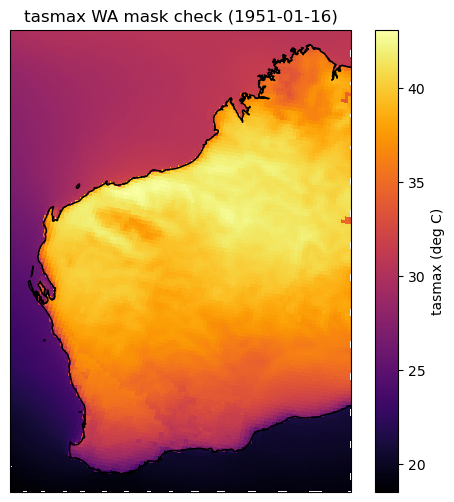

In [33]:
# Grab 2-D lat/lon from the loaded data for plotting
lat2d = tasmax_djf['lat']
lon2d = tasmax_djf['lon']

# Quick plot — first DJF time step
fig = plt.figure(figsize=(6, 6))
ax  = plt.axes(projection=ccrs.PlateCarree())
pcm = ax.pcolormesh(
    lon2d, lat2d, tasmax_djf.isel(time=0),
    transform=ccrs.PlateCarree(), shading='auto', cmap='inferno'
)
ax.coastlines(resolution='10m')
ax.add_feature(cfeature.STATES, linewidth=0.5)
ax.set_extent([LON_MIN, LON_MAX, LAT_MIN, LAT_MAX], crs=ccrs.PlateCarree())
plt.colorbar(pcm, ax=ax, label='tasmax (deg C)')
t0 = str(tasmax_djf.time.values[0])[:10]
plt.title(f'tasmax WA mask check ({t0})')
plt.show()


<div style="text-align: right">
  <a href="#top">Go back to top</a>
</div>

## DJF climatologies and climate change signal

### Method

1. **DJF annual mean**: for each DJF year, average the three monthly values (Dec of previous year + Jan + Feb).
2. **Reference climatology**: mean of all DJF annual means inside `REF_START`-`REF_END` (1980-2009).
3. **Future climatology**: mean of all DJF annual means inside `FUT_START`-`FUT_END` (2070-2099).
4. **Climate change signal** = future climatology minus reference climatology.

> The `djf_year` coordinate (assigned during loading) ensures December is correctly attributed to the following year's DJF season.


In [34]:
# --- Step 1: DJF annual mean for every year ---
# Group by djf_year and average the 3 DJF months for each year
djf_annual = tasmax_djf.groupby('djf_year').mean('time')
# djf_annual is indexed by djf_year (integer)

# --- Step 2: Reference climatology (e.g. 1980-2009) ---
djf_ref = (
    djf_annual
    .sel(djf_year=slice(REF_START, REF_END))
    .mean('djf_year')
)

# --- Step 3: Future climatology (e.g. 2070-2099) ---
djf_fut = (
    djf_annual
    .sel(djf_year=slice(FUT_START, FUT_END))
    .mean('djf_year')
)

# --- Step 4: Climate change signal ---
djf_signal = djf_fut - djf_ref

# WA spatial mean for a quick summary number
wa_valid = ~np.isnan(djf_ref.values)
print(f'DJF reference ({REF_START}-{REF_END}) WA mean : {float(djf_ref.values[wa_valid].mean()):.2f} deg C')
print(f'DJF future    ({FUT_START}-{FUT_END}, {SCENARIO}) WA mean : {float(djf_fut.values[wa_valid].mean()):.2f} deg C')
print(f'Climate change signal WA mean          : {float(djf_signal.values[wa_valid].mean()):.2f} deg C')


DJF reference (1980-2009) WA mean : 32.37 deg C
DJF future    (2070-2099, ssp370) WA mean : 35.60 deg C
Climate change signal WA mean          : 3.23 deg C


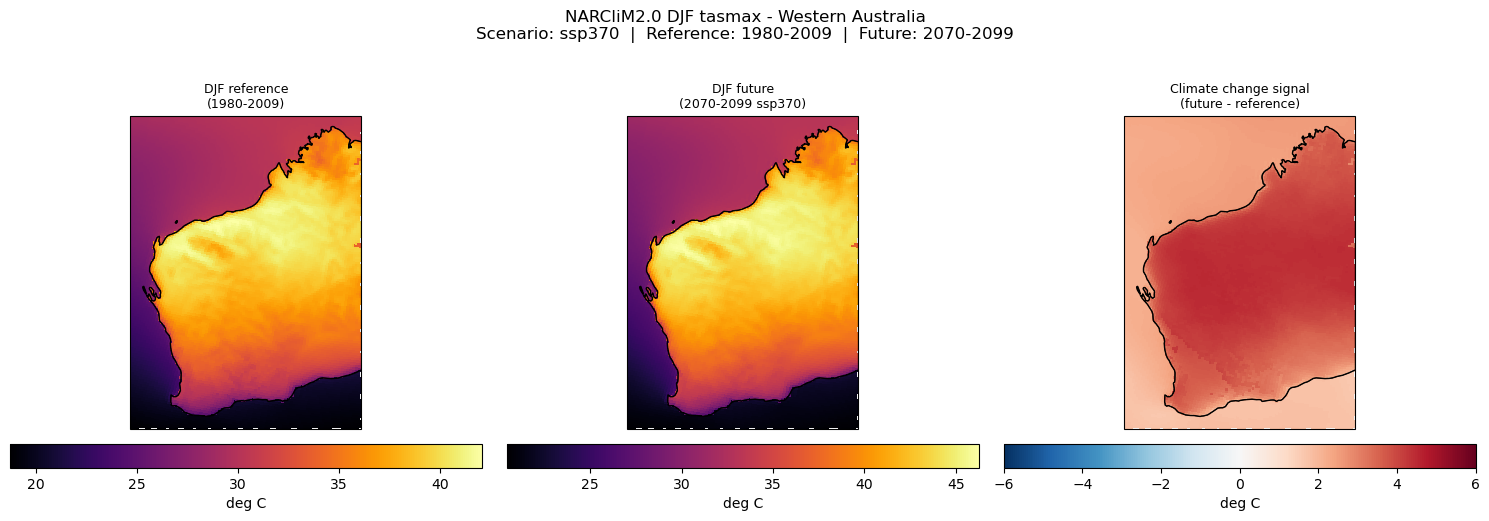

In [35]:
# --- Plot reference, future and signal side by side ---
fields = [
    (djf_ref,    f'DJF reference\n({REF_START}-{REF_END})',          'inferno', None, None),
    (djf_fut,    f'DJF future\n({FUT_START}-{FUT_END} {SCENARIO})',  'inferno', None, None),
    (djf_signal, 'Climate change signal\n(future - reference)',       'RdBu_r',  -6,   6),
]

fig, axes = plt.subplots(
    1, 3, figsize=(15, 5),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

for ax, (field, title, cmap, vmin, vmax) in zip(axes, fields):
    kw = dict(transform=ccrs.PlateCarree(), shading='auto', cmap=cmap)
    if vmin is not None:
        kw['norm'] = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)
    pcm = ax.pcolormesh(lon2d, lat2d, field, **kw)
    ax.set_extent([LON_MIN, LON_MAX, LAT_MIN, LAT_MAX], crs=ccrs.PlateCarree())
    ax.coastlines()
    ax.add_feature(cfeature.STATES, linewidth=0.5)
    ax.set_title(title, fontsize=9)
    plt.colorbar(pcm, ax=ax, orientation='horizontal', pad=0.04, label='deg C')

plt.suptitle(
    f'NARCliM2.0 DJF tasmax - Western Australia\n'
    f'Scenario: {SCENARIO}  |  Reference: {REF_START}-{REF_END}  |  Future: {FUT_START}-{FUT_END}',
    y=1.02
)
plt.tight_layout()
plt.show()


<div style="text-align: right">
  <a href="#top">Go back to top</a>
</div>

## DJF anomaly time series

For each DJF year from 1951 to 2100 the anomaly is:

$$\Delta T_{\mathrm{DJF}}(y) = \overline{T}_{\mathrm{DJF}}(y) - \overline{T}_{\mathrm{DJF}}^{\,\mathrm{ref}}$$

where $\overline{T}_{\mathrm{DJF}}^{\,\mathrm{ref}}$ is the DJF climatology over the reference period (1980-2009). The anomaly is then spatially averaged over the WA region to produce one number per year.


In [36]:
# --- Spatial mean over WA (nanmean ignores non-WA NaN cells) ---
djf_ts_wa = djf_annual.mean(dim=['rlat', 'rlon'])   # shape: (djf_year,)

# Reference value: WA-averaged DJF climatology over the reference period
ref_wa_mean = float(
    djf_ts_wa.sel(djf_year=slice(REF_START, REF_END)).mean().values
)

# DJF anomaly for every year (annual DJF mean minus reference climatology)
djf_anom_wa = djf_ts_wa - ref_wa_mean

years = djf_anom_wa['djf_year'].values
anom  = djf_anom_wa.values

# Split into historical and scenario segments
# Cap scenario at SCEN_END to exclude any artefact years
hist_mask = years <= HIST_END
scen_mask = (years > HIST_END) & (years <= SCEN_END)

print(f'Reference WA DJF mean ({REF_START}-{REF_END}): {ref_wa_mean:.2f} deg C')
print(f'Historical years : {years[hist_mask][0]} - {years[hist_mask][-1]} '
      f'({hist_mask.sum()} years)')
print(f'Scenario  years  : {years[scen_mask][0]} - {years[scen_mask][-1]} '
      f'({scen_mask.sum()} years)')


Reference WA DJF mean (1980-2009): 32.37 deg C
Historical years : 1951 - 2014 (64 years)
Scenario  years  : 2015 - 2100 (86 years)


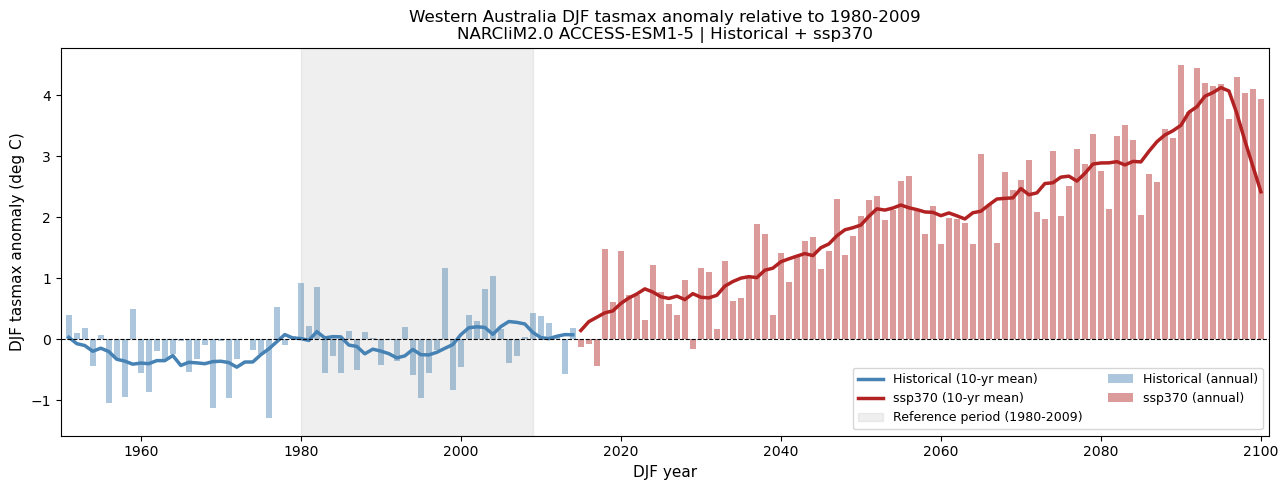

In [37]:
def running_mean(x, n=10):
    """Simple centred running mean (n-year window)."""
    return np.convolve(x, np.ones(n) / n, mode='same')


fig, ax = plt.subplots(figsize=(13, 5))

# Annual bars
ax.bar(years[hist_mask], anom[hist_mask],
       color='steelblue', alpha=0.45, label='Historical (annual)')
ax.bar(years[scen_mask], anom[scen_mask],
       color='firebrick',  alpha=0.45, label=f'{SCENARIO} (annual)')

# 10-year smoothed lines
ax.plot(years[hist_mask], running_mean(anom[hist_mask]),
        color='steelblue', lw=2.5, label='Historical (10-yr mean)')
ax.plot(years[scen_mask], running_mean(anom[scen_mask]),
        color='firebrick',  lw=2.5, label=f'{SCENARIO} (10-yr mean)')

# Reference period shading
ax.axvspan(REF_START, REF_END, color='grey', alpha=0.12,
           label=f'Reference period ({REF_START}-{REF_END})')
ax.axhline(0, color='black', lw=0.8, ls='--')

# Axis limits — cap at SCEN_END so no phantom 2101 bar appears
ax.set_xlim(HIST_START - 1, SCEN_END + 1)
ax.set_xlabel('DJF year', fontsize=11)
ax.set_ylabel('DJF tasmax anomaly (deg C)', fontsize=11)
ax.set_title(
    f'Western Australia DJF tasmax anomaly relative to {REF_START}-{REF_END}\n'
    f'NARCliM2.0 ACCESS-ESM1-5 | Historical + {SCENARIO}',
    fontsize=12
)
ax.legend(fontsize=9, ncol=2)
plt.tight_layout()
plt.show()


<div style="text-align: right">
  <a href="#top">Go back to top</a>
</div>

## Seasonal climatology maps

For completeness, seasonal mean maps (DJF / MAM / JJA / SON) are computed over the reference period. Because we loaded only DJF months above, we need to load the full annual data for the reference period here — but only for those years and only the WA subset.

> This cell loads ~30 files (one per year of the reference period) and applies the WA mask immediately, so memory usage stays low.


In [38]:
def load_annual_wa(urls, retries=3, wait=10):
    """
    Load ALL months (not just DJF) for a list of annual files,
    applying the WA mask immediately to save memory.
    """
    slices = []
    for i, url in enumerate(urls):
        yr = url.split('/')[-1].split('_mon_')[1][:4]
        print(f'  {i+1}/{len(urls)}: {yr}', end='  ')
        for attempt in range(retries):
            try:
                ds = xr.open_dataset(url)
                wa_mask = build_wa_mask(ds)
                da = kelvin_to_celsius(ds['tasmax'].where(wa_mask))
                da.load()
                slices.append(da)
                ds.close()
                break
            except OSError:
                if attempt < retries - 1:
                    print(f'retry...', end=' ')
                    time.sleep(wait)
                else:
                    raise
    print()
    return xr.concat(slices, dim='time')


# Build URL list for the reference period only
ref_urls = make_urls('historical', REF_START, REF_END)

print(f'Loading all months for reference period ({REF_START}-{REF_END})...')
tasmax_ref_full = load_annual_wa(ref_urls)
print('Done. Shape:', tasmax_ref_full.shape)


Loading all months for reference period (1980-2009)...
  1/30: 1980    2/30: 1981    3/30: 1982    4/30: 1983    5/30: 1984    6/30: 1985    7/30: 1986    8/30: 1987    9/30: 1988    10/30: 1989    11/30: 1990    12/30: 1991    13/30: 1992    14/30: 1993    15/30: 1994    16/30: 1995    17/30: 1996    18/30: 1997    19/30: 1998    20/30: 1999    21/30: 2000    22/30: 2001    23/30: 2002    24/30: 2003    25/30: 2004    26/30: 2005    27/30: 2006    28/30: 2007    29/30: 2008    30/30: 2009  
Done. Shape: (360, 321, 497)


In [39]:
# Seasonal climatology over the reference period
seasonal_clim = tasmax_ref_full.groupby('time.season').mean('time')

# Seasonal anomaly = each season minus the reference-period all-season mean
seasonal_anom = seasonal_clim - seasonal_clim.mean('season')

print('Seasons:', list(seasonal_anom.season.values))


Seasons: ['DJF', 'JJA', 'MAM', 'SON']


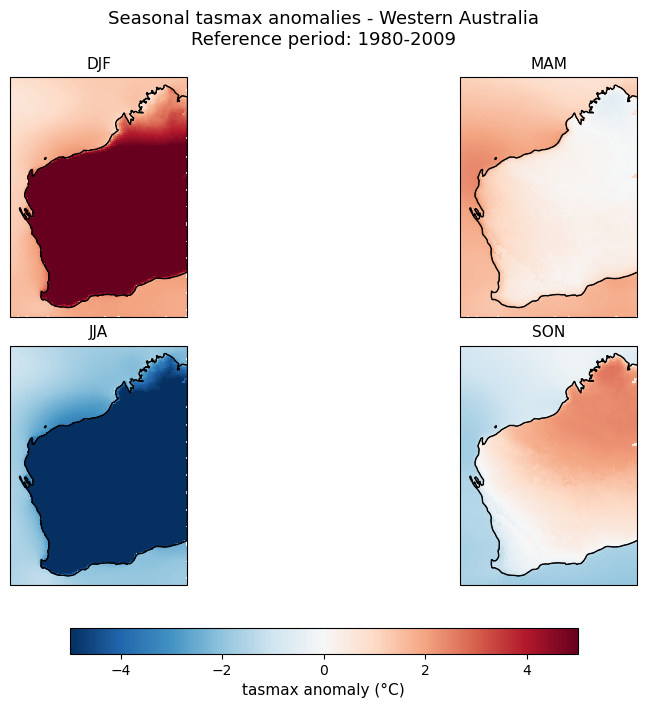

In [40]:
fig, axes = plt.subplots(
    2, 2, figsize=(9, 7),
    subplot_kw={'projection': ccrs.PlateCarree()},
    constrained_layout=True   # <-- handles spacing automatically
)

axes = axes.flatten()
norm = TwoSlopeNorm(vmin=-5, vcenter=0, vmax=5)

for ax, s in zip(axes, ['DJF', 'MAM', 'JJA', 'SON']):
    pcm = ax.pcolormesh(
        lon2d, lat2d, seasonal_anom.sel(season=s),
        transform=ccrs.PlateCarree(),
        shading='auto', cmap='RdBu_r', norm=norm
    )
    ax.set_extent([LON_MIN, LON_MAX, LAT_MIN, LAT_MAX], crs=ccrs.PlateCarree())
    ax.coastlines()
    ax.add_feature(cfeature.STATES, linewidth=0.5)
    ax.set_title(s, fontsize=11)

# Create a dedicated colorbar axis below all plots
cbar = fig.colorbar(
    pcm, ax=axes, orientation='horizontal',
    fraction=0.05, pad=0.08
)
cbar.set_label('tasmax anomaly (°C)', fontsize=11)

fig.suptitle(
    f'Seasonal tasmax anomalies - Western Australia\n'
    f'Reference period: {REF_START}-{REF_END}',
    fontsize=13
)

plt.show()

<div style="text-align: right">
  <a href="#top">Go back to top</a>
</div>

## Regrid for GIS export

The native WRF rotated grid is regridded to a regular 0.05-degree lat/lon grid using **xESMF bilinear regridding** for export to GIS platforms.


In [41]:
lon_new = np.arange(LON_MIN, LON_MAX + 0.05, 0.05)
lat_new = np.arange(LAT_MIN, LAT_MAX + 0.05, 0.05)
ds_out  = xr.Dataset({'lat': (['lat'], lat_new), 'lon': (['lon'], lon_new)})

# Build regridder from the DJF reference field (representative grid)
regridder = xe.Regridder(djf_ref, ds_out, method='bilinear', periodic=False)

djf_ref_ll    = regridder(djf_ref)
djf_fut_ll    = regridder(djf_fut)
djf_signal_ll = regridder(djf_signal)
seasonal_anom_ll = regridder(seasonal_anom)

print('Regridded shapes:')
print('  djf_signal_ll  :', djf_signal_ll.shape)
print('  seasonal_anom_ll:', seasonal_anom_ll.shape)


Regridded shapes:
  djf_signal_ll  : (461, 342)
  seasonal_anom_ll: (4, 461, 342)


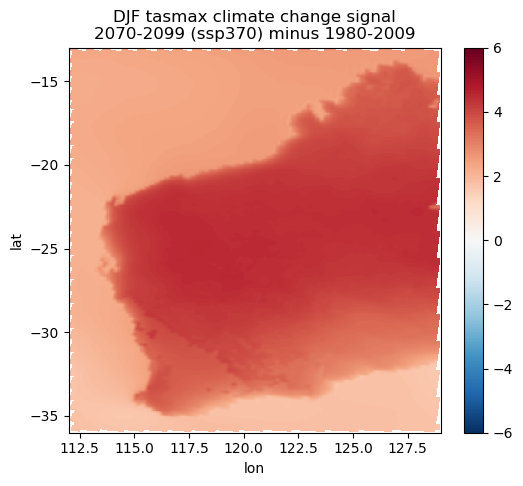

In [42]:
djf_signal_ll.plot(cmap='RdBu_r', vmin=-6, vmax=6, figsize=(6, 5))
plt.xlim(LON_MIN, LON_MAX)
plt.ylim(LAT_MIN, LAT_MAX)
plt.title(
    f'DJF tasmax climate change signal\n'
    f'{FUT_START}-{FUT_END} ({SCENARIO}) minus {REF_START}-{REF_END}'
)
plt.show()


<div style="text-align: right">
  <a href="#top">Go back to top</a>
</div>

## Export products

Four NetCDF files are saved:

1. DJF reference climatology (regridded)
2. DJF future climatology (regridded)
3. DJF climate change signal (regridded)
4. Perth monthly time series (DJF months, native grid)


In [43]:
output_dir = Path('output')
output_dir.mkdir(parents=True, exist_ok=True)

# 1-3: DJF fields
djf_ref_ll.to_netcdf(output_dir / f'tasmax_DJF_ref_{REF_START}-{REF_END}_WA.nc')
djf_fut_ll.to_netcdf(output_dir / f'tasmax_DJF_fut_{FUT_START}-{FUT_END}_{SCENARIO}_WA.nc')
djf_signal_ll.to_netcdf(
    output_dir / f'tasmax_DJF_signal_{SCENARIO}_{FUT_START}-{FUT_END}_vs_{REF_START}-{REF_END}_WA.nc'
)

# 4: Perth DJF time series (from the DJF-only loaded data)
rlat_idx, rlon_idx = nearest_point(tasmax_djf, TARGET_LON, TARGET_LAT)
perth_djf = tasmax_djf.isel(rlat=rlat_idx, rlon=rlon_idx)
perth_djf.to_netcdf(
    output_dir / f'tasmax_DJF_{TARGET_LABEL.lower()}_{HIST_START}-{SCEN_END}_{SCENARIO}.nc'
)

for f in sorted(output_dir.iterdir()):
    print('Exported:', f)


Exported: output/.DS_Store
Exported: output/perth_tasmax_2015.nc
Exported: output/regridded
Exported: output/tasmax_DJF_fut_2070-2099_ssp370_WA.nc
Exported: output/tasmax_DJF_perth_1951-2100_ssp370.nc
Exported: output/tasmax_DJF_ref_1980-2009_WA.nc
Exported: output/tasmax_DJF_signal_ssp370_2070-2099_vs_1980-2009_WA.nc
Exported: output/tasmax_anomaly_WA_2015.nc


<div style="text-align: right">
  <a href="#top">Go back to top</a>
</div>

## Interpretation

### DJF climate change signal
The climate change signal map shows the projected change in DJF maximum temperature between the 1980-2009 reference period and 2070-2099 under the selected scenario. Positive values (red) indicate warming; the spatial pattern shows which parts of WA are projected to warm most strongly in summer.

### DJF anomaly time series
The time series tracks the WA-averaged DJF temperature relative to the 1980-2009 mean. The historical segment (blue) shows natural variability; the future segment (red) shows the combined effect of natural variability and the forced warming trend under the chosen scenario.

### Seasonal climatology
The four-panel map shows how each season departs from the reference-period annual mean. Summer (DJF) brings the strongest positive anomalies in northern and inland WA; winter (JJA) is the coolest season; autumn and spring are transitional.

### Technical note on DJF convention
December is attributed to the *following* year's DJF season throughout this notebook. DJF-2015 therefore comprises December 2014, January 2015, and February 2015.


This notebook implements a reproducible, memory-efficient workflow:

- **All parameters in one configuration cell** — change scenario, period, or region without touching analysis code.
- **Time chunking** — only DJF months are streamed from THREDDS, reducing download volume by ~75%.
- **Correct DJF convention** — December is assigned to the following year.
- **Correct anomaly definition** — DJF anomaly = DJF mean minus DJF climatology, not minus annual mean.
- **30-year averages** — robust climatologies that reduce the influence of interannual variability.


<div style="text-align: right">
  <a href="#top">Go back to top</a>
</div>

## Next steps

All of the following require only changes to the **Configuration** cell:

- **Different scenario**: set `SCENARIO = 'ssp126'` for a low-emissions pathway.
- **Different reference period**: adjust `REF_START` / `REF_END`.
- **Mid-century future**: set `FUT_START = 2040`, `FUT_END = 2069`.
- **Different season**: set `SEASON = 'JJA'` (requires adapting `DJF_MONTHS`).
- **Sub-region**: tighten `LON_MIN/MAX`, `LAT_MIN/MAX` for e.g. the Pilbara or Kimberley.
- **Different variable**: replace `tasmax` with `tasmin` or `pr` in `THREDDS_TMPL`.


<div style="text-align: right">
  <a href="#top">Go back to top</a>
</div>